# Fisher Matrix Uncertainty Consistency Checks

This notebook is hardcoded to work for a 6 filter gulls run and wzk obs group = 3.

Start a new Jupyter kernel using:
```bash
python -m ipykernel install --user --name GullsPosteriors --display-name "Python (GullsPosteriors)"
jupyter notebook --no-browser --port=8888
```

## Set Up

In [1]:
# package imports
import pandas as pd
import numpy as np
import yaml
import os
import matplotlib.pyplot as plt
import corner
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# data loading
completed_bins = ["m-10", "m00", "m10"]
data = {}
for mass_bin in completed_bins:
    data_dir = "../filter_selection/6f_overguide_" + mass_bin + "/"
    dstore = pd.HDFStore(data_dir + 'analysis/6f_overguide_' + mass_bin + '.det.hdf5','r')
    data[mass_bin] = {"data_dir": data_dir, "dstore": dstore, "wzk": None, "unc": None, "event_list": None}

In [3]:
# Checking whats in the last hdf5 file
print(dstore.info())

<class 'pandas.io.pytables.HDFStore'>
File path: ../filter_selection/6f_overguide_m10/analysis/6f_overguide_m10.det.hdf5
/overguide_6hcc_wrf            frame_table  (typ->appendable,nrows->34921,ncols->304,indexers->[index],dc->[])
/overguide_6hcc_wrk            frame_table  (typ->appendable,nrows->34859,ncols->304,indexers->[index],dc->[])
/overguide_6hcc_wyf            frame_table  (typ->appendable,nrows->34954,ncols->304,indexers->[index],dc->[])
/overguide_6hcc_wyk            frame_table  (typ->appendable,nrows->34895,ncols->304,indexers->[index],dc->[])
/overguide_6hcc_wzf            frame_table  (typ->appendable,nrows->34928,ncols->304,indexers->[index],dc->[])
/overguide_6hcc_wzk            frame_table  (typ->appendable,nrows->34859,ncols->304,indexers->[index],dc->[])


In [4]:
# verifying the keys
print(dstore.keys())

['/overguide_6hcc_wrf', '/overguide_6hcc_wrk', '/overguide_6hcc_wyf', '/overguide_6hcc_wyk', '/overguide_6hcc_wzf', '/overguide_6hcc_wzk']


We need the wzk data, corresponding to `ObsGroup=3`.

In [5]:
for mass_bin in completed_bins:
    dstore = data[mass_bin]["dstore"]
    wzk = dstore['/overguide_6hcc_wzk']
    data[mass_bin]["wzk"] = wzk.copy()
    data[mass_bin]["dstore"] = None  # free up memory
# Show all columns when using head()
pd.set_option('display.max_columns', None)
data["m00"]["wzk"].head()

,EventID,SubRun,Field,galactic_l,galactic_b,ra_deg,dec_deg,SourceID,Source_mul,Source_mub,Source_Vr,Source_U,Source_V,Source_W,Source_iMass,Source_CL,Source_age,Source_Teff,Source_logg,Source_pop,Source_Mass,Source_Mbol,Source_Radius,Source_Fe_H,Source_l,Source_b,Source_RA20000,Source_DEC20000,Source_Dist,Source_x,Source_y,Source_z,Source_A_Ks,Source_alpha_Fe,LensID,Lens_mul,Lens_mub,Lens_Vr,Lens_U,Lens_V,Lens_W,Lens_iMass,Lens_CL,Lens_age,Lens_Teff,Lens_logg,Lens_pop,Lens_Mass,Lens_Mbol,Lens_Radius,Lens_Fe_H,Lens_l,Lens_b,Lens_RA20000,Lens_DEC20000,Lens_Dist,Lens_x,Lens_y,Lens_z,Lens_A_Ks,Lens_alpha_Fe,u0lens1,alpha,t0lens1,tref,tcroin,ucroin,rcroin,tE_ref,tE_helio,rE,thetaE,rho,piE,phi_pi,piEN,piEE,murel_helio_alpha,murel_helio_delta,murel_helio_l,murel_helio_b,murel_helio_lambda,murel_helio_beta,murel_helio,murel_ref_alpha,murel_ref_delta,murel_ref_l,murel_ref_b,murel_ref_lambda,murel_ref_beta,murel_ref,vtilde_helio,vtilde_ref,v_ref,vtilde_helio_N,vtilde_helio_E,vtilde_ref_N,vtilde_ref_E,v_ref_N,v_ref_E,piEll,piErp,vt,LDgamma,Planet_mass,Planet_semimajoraxis,Planet_inclination,Planet_orbphase,Planet_q,Planet_s,Planet_period,u0max,t0range,weight_scale,raw_weight,weight,Source_R062,Source_Z087,Source_Y106,Source_J129,Source_W146,Source_H158,Source_F184,Source_K213,Source_2MASS_Ks,Source_2MASS_J,Source_2MASS_H,Source_Bessell_U,Source_Bessell_B,Source_Bessell_V,Source_Bessell_I,Source_Bessell_R,Source_Kepler_Kp,Source_TESS,Source_DECam_z,Source_DECam_u,Source_DECam_g,Source_DECam_r,Source_DECam_i,Source_DECam_Y,Source_Gaia_G_EDR3,Source_Gaia_BP_EDR3,Source_Gaia_RP_EDR3,Source_VISTA_Z,Source_VISTA_Y,Source_VISTA_J,Source_VISTA_H,Source_VISTA_Ks,Lens_R062,Lens_Z087,Lens_Y106,Lens_J129,Lens_W146,Lens_H158,Lens_F184,Lens_K213,Lens_2MASS_Ks,Lens_2MASS_J,Lens_2MASS_H,Lens_Bessell_U,Lens_Bessell_B,Lens_Bessell_V,Lens_Bessell_I,Lens_Bessell_R,Lens_Kepler_Kp,Lens_TESS,Lens_DECam_z,Lens_DECam_u,Lens_DECam_g,Lens_DECam_r,Lens_DECam_i,Lens_DECam_Y,Lens_Gaia_G_EDR3,Lens_Gaia_BP_EDR3,Lens_Gaia_RP_EDR3,Lens_VISTA_Z,Lens_VISTA_Y,Lens_VISTA_J,Lens_VISTA_H,Lens_VISTA_Ks,Obs_0_fs,Obs_1_fs,Obs_2_fs,Obs_3_fs,Obs_4_fs,Obs_5_fs,NumObsGroups,ErrorFlag,ObsGroup_0_flatlc,ObsGroup_0_flatchi2,ObsGroup_0_FiniteSourceflag,ObsGroup_0_chi2,ObsGroup_1_flatlc,ObsGroup_1_flatchi2,ObsGroup_1_FiniteSourceflag,ObsGroup_1_chi2,ObsGroup_2_flatlc,ObsGroup_2_flatchi2,ObsGroup_2_FiniteSourceflag,ObsGroup_2_chi2,ObsGroup_3_flatlc,ObsGroup_3_flatchi2,ObsGroup_3_FiniteSourceflag,ObsGroup_3_chi2,ObsGroup_4_flatlc,ObsGroup_4_flatchi2,ObsGroup_4_FiniteSourceflag,ObsGroup_4_chi2,ObsGroup_5_flatlc,ObsGroup_5_flatchi2,ObsGroup_5_FiniteSourceflag,ObsGroup_5_chi2,ObsGroup_0_t0_err,ObsGroup_0_log_tE_err,ObsGroup_0_u0_err,ObsGroup_0_alpha_err,ObsGroup_0_log_s_err,ObsGroup_0_log_q_err,ObsGroup_0_log_rho_err,ObsGroup_0_piEN_err,ObsGroup_0_piEE_err,ObsGroup_0_Fbase0_err,ObsGroup_0_fs0_err,ObsGroup_0_Fbase1_err,ObsGroup_0_fs1_err,ObsGroup_0_Fbase3_err,ObsGroup_0_fs3_err,ObsGroup_1_t0_err,ObsGroup_1_log_tE_err,ObsGroup_1_u0_err,ObsGroup_1_alpha_err,ObsGroup_1_log_s_err,ObsGroup_1_log_q_err,ObsGroup_1_log_rho_err,ObsGroup_1_piEN_err,ObsGroup_1_piEE_err,ObsGroup_1_Fbase0_err,ObsGroup_1_fs0_err,ObsGroup_1_Fbase1_err,ObsGroup_1_fs1_err,ObsGroup_1_Fbase4_err,ObsGroup_1_fs4_err,ObsGroup_2_t0_err,ObsGroup_2_log_tE_err,ObsGroup_2_u0_err,ObsGroup_2_alpha_err,ObsGroup_2_log_s_err,ObsGroup_2_log_q_err,ObsGroup_2_log_rho_err,ObsGroup_2_piEN_err,ObsGroup_2_piEE_err,ObsGroup_2_Fbase0_err,ObsGroup_2_fs0_err,ObsGroup_2_Fbase2_err,ObsGroup_2_fs2_err,ObsGroup_2_Fbase3_err,ObsGroup_2_fs3_err,ObsGroup_3_t0_err,ObsGroup_3_log_tE_err,ObsGroup_3_u0_err,ObsGroup_3_alpha_err,ObsGroup_3_log_s_err,ObsGroup_3_log_q_err,ObsGroup_3_log_rho_err,ObsGroup_3_piEN_err,ObsGroup_3_piEE_err,ObsGroup_3_Fbase0_err,ObsGroup_3_fs0_err,ObsGroup_3_Fbase2_err,ObsGroup_3_fs2_err,ObsGroup_3_Fbase4_err,ObsGroup_3_fs4_err,ObsGroup_4_t0_err,ObsGroup_4_log_tE_err,ObsGroup_4_u0_err,ObsGroup_4_alpha_err,ObsGroup_4_log_s_err,ObsGroup_4_log_

Narrowing down the data to just what we need, so that it's a little less overwhelming and annoying to use.

In [6]:
# Select event identifiers + parameter uncertainties
for mass_bin in completed_bins:
    wzk = data[mass_bin]["wzk"]
    keep = ['EventID','SubRun','Field']
    for col in wzk.columns:
        if col.startswith("ObsGroup_3") and col.endswith("_err"):
            keep.append(col)
        if "weight" in col:
            keep.append(col)
    data[mass_bin]["unc"] = wzk[keep].copy()
    data[mass_bin]["wzk"] = None  # free memory

data["m00"]["unc"].head()

,EventID,SubRun,Field,weight_scale,raw_weight,weight,ObsGroup_3_t0_err,ObsGroup_3_log_tE_err,ObsGroup_3_u0_err,ObsGroup_3_alpha_err,ObsGroup_3_log_s_err,ObsGroup_3_log_q_err,ObsGroup_3_log_rho_err,ObsGroup_3_piEN_err,ObsGroup_3_piEE_err,ObsGroup_3_Fbase0_err,ObsGroup_3_fs0_err,ObsGroup_3_Fbase2_err,ObsGroup_3_fs2_err,ObsGroup_3_Fbase4_err,ObsGroup_3_fs4_err,final_weight
3,3,0,881,1.0,1.102530,0.026375,0.285722,0.000012,0.052857,0.005453,0.001939,0.051686,0.008203,1.261230,0.303288,0.000025,0.066976,0.000397,0.656904,0.000263,2.595496,0.000805
35,35,0,881,1.0,0.439049,0.135304,0.005767,0.000291,0.000059,0.003245,0.006548,0.087216,0.345385,0.060768,0.002243,0.000030,0.000544,0.000340,0.000822,0.000278,0.000421,0.004131
73,73,0,881,1.0,2.312879,0.404571,0.012569,0.003185,0.000902,0.002432,0.005347,0.118828,0.446355,0.761270,0.018013,0.000009,0.002589,0.000090,0.002512,0.000082,0.002361,0.012351
80,80,0,881,1.0,0.551608,0.019092,172.824502,0.000044,41.118428,3.233844,0.511176,0.602461,4.105537,18.221770,6.129918,0.000020,0.063885,0.000232,0.079626,0.000174,0.039331,0.000583
125,125,0,881,1.0,1.229604,0.466852,0.017766,0.001195,0.019185,0.113504,0.002272,0.027711,0.013546,18.936595,0.681085,0.000029,0.000516,0.000462,0.000905,0.000221,0.000307,0.014252


## Uncertainties from Each Source

In [7]:
# for each event in the output (posteriors) folder, find the corresponding event in the input (truth) folder
# and compare the uncertainties on the fitted parameters to the true parameter values
# to see if the uncertainties are reasonable
for mass_bin in completed_bins:
    print(f"Processing mass bin: {mass_bin}")
    unc = data[mass_bin]["unc"]
    data_dir = data[mass_bin]["data_dir"] + mass_bin + "/"
    output_dir = data_dir + "posteriors/"  # path to the mcmc outputs

    event_list = {}  # dictionary to store event information and avoid saving duplicates

    for filename in os.listdir(output_dir):
        if "samples" in filename:
            print(filename)
            
            # load the sampling parameter file
            prm_file = None
            for suffix in ("emcee_samples.npy", "dynesty_samples.npy", "post_samples.npy"):
                if suffix in filename:
                    prm_file = filename.replace(suffix, "sampling.prm")
                    break
            if prm_file is None:
                print(f"  Unable to infer prm filename for {filename}, skipping")
                continue
            
            # Skip if already processed this prm file
            # There sill be duplicates, due to there being multiple files per events containing "samples",
            # but we only want to process each event once.
            if prm_file in event_list:
                print(f"  Skipping {prm_file} - already processed")
                continue
            
            # get labels from the prm yml file
            prm_path = os.path.join(output_dir, prm_file)
            if not os.path.exists(prm_path):
                print(f"  prm file {prm_file} not found, skipping")
                raise FileNotFoundError(f"prm file {prm_file} not found")
            with open(prm_path, 'r') as f:
                prm_labels = yaml.safe_load(f)
            #print(prm_labels)
        
            # get the parameter labels from the prm file
            # model_config > parameter_labels
            parameter_labels = prm_labels['model_config']['parameter_labels']
            #print(parameter_labels)
            # event_truths > EventID, Field, SubRun
            event_id = int(prm_labels['event_truths']['EventID'])
            field = int(prm_labels['event_truths']['Field'])
            subrun =  int(prm_labels['event_truths']['SubRun'])
            lcname = prm_labels['event_truths']['lcname']
            truths = prm_labels['event_truths']['params']
            truths = truths[0:len(parameter_labels)]  # drop the LOM parameters
            truths_series = pd.Series(truths, index=parameter_labels)  # not logged, indexed by param name
        
            # store in a dictionary
            event_list[prm_file] = {}
            event_list[prm_file]["event_id"] = event_id
            event_list[prm_file]["field"] = field
            event_list[prm_file]["subrun"] = subrun
            event_list[prm_file]["lcname"] = lcname
            event_list[prm_file]["parameter_labels"] = parameter_labels
            event_list[prm_file]["truths"] = truths_series  # Store the actual truth values!
        
            # Extract prior sigmas from prm file
            prior_sigmas = {}
            if 'prior_config' in prm_labels:
                for key, val in prm_labels['prior_config'].items():
                    if key.startswith('sigma_'):
                        param_name = key.replace('sigma_', '')
                        # Map to our parameter naming convention
                        if param_name.startswith('log'):
                            param_name = param_name.replace('log', '')
                            prior_sigmas[f"log_{param_name}_err"] = val
                        else:
                            prior_sigmas[f"{param_name}_err"] = val
            event_list[prm_file]["prior_uncertainties"] = prior_sigmas

            print(f"Processing EventID: {event_id}, Field: {field}, SubRun: {subrun}")
            # rename event labels to remove ObsGroup_3
            column_rename = unc.columns.str.replace("ObsGroup_3_","")
            unc.columns = column_rename
            # find the corresponding event in the input data
            #event = unc[(unc['EventID'] == event_id) & (unc['Field'] == field) & (unc['SubRun'] == subrun)]
            event = unc.query("EventID == @event_id and Field == @field and SubRun == @subrun")
            if len(event) == 0:
                print(f"Event {event_id}_{field}_{subrun} not found in input data")
                continue
            event = event.iloc[0]
            print(event)
            event_list[prm_file]["simulation_metadata"] = event

            # now load the posterior samples
            samples = np.load(output_dir + filename)
            print(samples.shape)
        
            # Try to load flux parameter blobs
            blobs_filename = filename.replace("samples.npy", "blobs.npy")
            blobs_keys_filename = filename.replace("samples.npy", "blobs_keys.npy")
            blobs_path = output_dir + blobs_filename
            blobs_keys_path = output_dir + blobs_keys_filename
            
            if os.path.exists(blobs_path) and os.path.exists(blobs_keys_path):
                print(f"  Loading flux parameter blobs from {blobs_filename}")
                blobs = np.load(blobs_path)
                blobs_keys = np.load(blobs_keys_path, allow_pickle=True)
                blobs_keys = [k.decode() if isinstance(k, bytes) else str(k) for k in blobs_keys]
                print(f"  Blobs shape: {blobs.shape}")
                print(f"  Blobs columns: {list(blobs_keys)}")
                
                # Stack blobs onto samples: [n_samples, n_params + n_flux_params]
                # Blobs are per-observatory: Fs_0, FB_0, Fbaseline_0, Fs_1, FB_1, Fbaseline_1, ...
                if blobs.shape[0] == samples.shape[0]:
                    samples = np.hstack([samples, blobs])
                    print(f"  Combined samples shape: {samples.shape}")
                    # Update parameter labels to include flux parameters
                    parameter_labels = parameter_labels + list(blobs_keys)
                else:
                    print(f"  Warning: Blobs shape mismatch ({blobs.shape[0]} vs {samples.shape[0]}), skipping")
            else:
                print(f"  No blobs files found, flux parameters not available")
            
            event_list[prm_file]["samples"] = samples
            event_list[prm_file]["parameter_labels"] = parameter_labels  # Update with flux params if loaded
        
            # Parse the light-curve header
            lc_file = os.path.join(data_dir, lcname)
            header_lines = []
            with open(lc_file) as fh:
                for _ in range(16):
                    header_lines.append(next(fh))
                    
            # Extract source fluxes:
            # Find the #fs: line, split it, and turn the trailing numbers into floats – that gives you the true source flux for every band.
            fs_line = next(line for line in header_lines if line.startswith("#fs:"))
            fs_values = [float(x) for x in fs_line.split()[1:]]
            print(f"True source fluxes: {fs_values}")
            
            # Pick the right bands:
            obs_group = prm_labels["plotting_config"]["obs_group"]  # 3 for filter selection 6f_overguide_*
            # In the header, locate the line that starts with #Obsgroup: {obs_group} and take its last three integers; 
            # those are the band indices used in the fit (e.g., 0, 2, 4).
            obsgroup_line = next(line for line in header_lines if line.startswith(f"#Obsgroup: {obs_group}"))
            obs_group_band_indices = [int(x) for x in obsgroup_line.split()[-3:]]
            print(f"Observatory group {obs_group} uses band indices: {obs_group_band_indices}")
            
            # Construct truths for the flux labels:
            # If the blobs provide only a subset, just check if label in parameter_labels before attaching.
            for b in obs_group_band_indices:
                fs_key = f"Fs_{b}"
                fbaseline_key = f"Fbaseline_{b}"
                fb_key = f"FB_{b}"
                if fs_key not in parameter_labels:
                    print(f"  Flux parameters for band {b} not in samples, skipping flux truths")
                    continue
                else:
                    print(f"  Adding flux truths for band {b}")
                    Fs = fs_values[b]
                    truths_series[f"Fs_{b}"] = Fs
                if fbaseline_key not in parameter_labels:
                    print(f"  Fbaseline parameter for band {b} not in samples, skipping")
                    continue
                else:
                    truths_series[f"Fbaseline_{b}"] = 1.0
                if fb_key not in parameter_labels:
                    print(f"  FB parameter for band {b} not in samples, skipping")
                    continue
                else:
                    truths_series[f"FB_{b}"] = 1.0 - Fs   # since fluxes are normalized to unity

            # Verify that truths_series and parameter_labels are aligned
            missing_truths = [label for label in parameter_labels if label not in truths_series.index]
            if missing_truths:
                # print mass bin and event identifier
                print(f"Mass bin: {mass_bin}, EventID: {event_id}, Field: {field}, SubRun: {subrun}") 
                raise ValueError(f"Missing truths for parameters: {missing_truths}")

            # get fisher derivatives from the lightcurve file
            # load the lightcurve file, ignoring comment lines and the first row (because the header is wrong)
            lc_data = np.loadtxt(lc_file, comments='#', skiprows=16)
            # hard code column names
            lc_columns = [
                "Simulation_time", "measured_relative_flux", "measured_relative_flux_error",
                "true_relative_flux", "true_relative_flux_error", "observatory_code",
                "saturation_flag", "best_single_lens_fit", "parallax_shift_t",
                "parallax_shift_u", "BJD", "source_x", "source_y", "lens1_x",
                "lens1_y", "lens2_x", "lens2_y", "parallax_shift_x",
                "parallax_shift_y", "parallax_shift_z", "dF_t0", "dF_tE",
                "dF_u0", "dF_alpha", "dF_s", "dF_q", "dF_rs", "dF_piEN",
                "dF_piEE", "dF_Fbase0", "dF_fs0",
                "dF_Fbase1", "dF_fs1", "dF_Fbase2", "dF_fs2",
                "dF_Fbase3", "dF_fs3", "dF_Fbase4", "dF_fs4",
                "dF_Fbase5", "dF_fs5"
            ]
            lc_df = pd.DataFrame(lc_data, columns=lc_columns)
        
            # load observatories from the config file
            config_file = os.path.join(data_dir, ".gulls_config.json")
            config = json.load(open(config_file))
            observatories = config['obs_list']
            # filter the lightcurve for data with observatory_code in observatories
            lc_df = lc_df[lc_df['observatory_code'].isin(observatories)]
            print(f"Number of data points after filtering for observatories: {len(lc_df)}")
        
            # Fisher
            # Construct the Fisher matrix (lightcurve data with dF_ columns)
            dF_columns = [col for col in lc_df.columns if col.startswith("dF_")]
            # exclude flux parameter that aren't in the observatories
            for i in range(6):
                if i not in observatories:
                    dF_columns.remove(f"dF_Fbase{i}")
                    dF_columns.remove(f"dF_fs{i}")
            J = lc_df[dF_columns].to_numpy(dtype=float)
            # measurement errors (must be > 0)
            sigma = lc_df["measured_relative_flux_error"].to_numpy(dtype=float)
            Jw = J / sigma[:, None]
            Fisher = Jw.T @ Jw
            # Invert the Fisher matrix to get the covariance matrix
            try:
                Cov = np.linalg.inv(Fisher)
            except np.linalg.LinAlgError:
                print("Fisher matrix is singular, cannot invert")
                continue
            # get the uncertainties from the covariance matrix
            fisher_unc = np.sqrt(np.diag(Cov))
            # convert to a dataframe for easy access
            Cov_df = pd.DataFrame(Cov, index=dF_columns, columns=dF_columns)
            # rename dF_param to param_err or log_param_err
            dF_to_param = {}
            for dF_col in dF_columns:
                # strip "dF_" prefix
                param = dF_col.replace("dF_", "")
                # map rs -> rho for labeling
                if param == "rs":
                    param = "rho"
                # add log_ prefix if needed
                if param in ["s", "q", "rho", "tE"]:
                    dF_to_param[dF_col] = f"log_{param}_err"
                else:
                    dF_to_param[dF_col] = f"{param}_err"
            fisher_unc_series = pd.Series(fisher_unc, index=dF_columns)
            fisher_unc_series = fisher_unc_series.rename(dF_to_param)
                
            # compute the 16, 50, 84 percentiles of the samples for each parameter
            print(f"Number of samples: {samples.shape[0]}")
            percentiles = np.percentile(samples, [16, 50, 84], axis=0)
            mcmc_unc = {}
            print("Percentiles (16, 50, 84):")
            for i, label in enumerate(parameter_labels):
                p16, p50, p84 = percentiles[:, i]
                err_minus = p50 - p16
                err_plus = p84 - p50
                
                # map label to the expected key (skip flux parameters that don't have Fisher/HDF5 equivalents)
                if label.startswith('Fs_') or label.startswith('FB_') or label.startswith('Fbaseline_'):
                    # Flux parameters - just store percentiles, no comparison to Fisher/HDF5
                    mcmc_unc[label] = (p50, err_minus, err_plus)
                    print(f"{label}: {p50:.3f} (+{err_plus:.3f}/-{err_minus:.3f})")
                else:
                    # Physical parameters - compare to Fisher and HDF5
                    label_key = f"log_{label}_err" if label in ["s", "q", "rho", "tE"] else f"{label}_err"
                    mcmc_unc[label_key] = (p50, err_minus, err_plus)
                    
                    print(f"{label_key}: {p50:.3f} (+{err_plus:.3f}/-{err_minus:.3f})")
                    if label_key in event.index:
                        print(f" hdf5 err: {event[label_key]:.3f}")
                    if label_key in fisher_unc_series.index:
                        print(f" fisher err: {fisher_unc_series[label_key]:.3f}")

            event_list[prm_file]["mcmc_uncertainties"] = mcmc_unc
            event_list[prm_file]["fisher_uncertainties"] = fisher_unc_series
            event_list[prm_file]["fisher_covariance"] = Cov_df  # Store full covariance matrix!
            just_modelling_parameters = fisher_unc_series.index.tolist()
            event_list[prm_file]["hdf5_uncertainties"] = event[just_modelling_parameters]

            print("\n")
            
            data[mass_bin]["event_list"] = event_list


Processing mass bin: m-10
128_2_83_post_samples.npy
Processing EventID: 83, Field: 128, SubRun: 2
EventID          83.000000
SubRun            2.000000
Field           128.000000
weight_scale      1.000000
raw_weight        1.699199
weight            0.117827
t0_err            0.262093
log_tE_err        0.009747
u0_err            0.000631
alpha_err         0.005639
log_s_err         0.000295
log_q_err         0.233011
log_rho_err       0.105127
piEN_err          0.378823
piEE_err          0.148484
Fbase0_err        0.000036
fs0_err           0.001527
Fbase2_err        0.001005
fs2_err           0.025318
Fbase4_err        0.000230
fs4_err           0.005756
final_weight      0.005450
Name: 83, dtype: float64
(300000, 9)
  No blobs files found, flux parameters not available
True source fluxes: [0.210383, 0.213472, 0.244016, 0.085191, 0.0669395, 0.233254]
Observatory group 3 uses band indices: [0, 2, 4]
  Flux parameters for band 0 not in samples, skipping flux truths
  Flux parameters fo

In [ ]:
import pickle
from pathlib import Path

# Optionally close or remove the open stores before saving
for mass_bin, entry in data.items():
    if isinstance(entry["dstore"], pd.HDFStore):
        entry["dstore"].close()
        entry["dstore"] = None    # or del entry["dstore"]

cache_path = Path.cwd() / "data_cache.pkl"  # adjust to the folder you prefer

In [ ]:
# Save
with cache_path.open("wb") as f:
    pickle.dump(data, f)

In [18]:
# Load (later)
with cache_path.open("rb") as f:
    data = pickle.load(f)

### Singular Matrix

Just debugging stuff RE signualr matricies.

In [19]:
# After J, sigma, Jw are built:
import numpy as np

n_obs, n_params = J.shape
print("J shape (n_obs, n_params):", J.shape)
print("Number of non-NaN observations:", np.sum(~np.isnan(J).any(axis=1)))

# check sigma
print("sigma: min, median, max:", np.nanmin(sigma), np.nanmedian(sigma), np.nanmax(sigma))
if np.any(sigma <= 0):
    print("Found non-positive sigma values:", np.where(sigma <= 0)[0][:10])
if np.any(np.isnan(sigma)):
    print("Found NaNs in sigma:", np.where(np.isnan(sigma))[0][:10])

# check for zero/constant derivative columns
col_norms = np.linalg.norm(J, axis=0)
zero_cols = np.where(col_norms == 0)[0]
small_cols = np.where(col_norms < 1e-12)[0]
print("zero-norm columns:", zero_cols.tolist())
print("very small-norm columns:", small_cols.tolist())

# check linear dependence with SVD
U, svals, Vt = np.linalg.svd(Jw, full_matrices=False)
print("Singular values of weighted Jacobian (descending):", svals)
rank = np.sum(svals > 1e-12 * svals[0])
print("Estimated rank of Jw:", rank, " / ", n_params)
print("Condition number (smax/smin):", (svals[0] / svals[-1]) if svals[-1] > 0 else np.inf)

# show which singular vectors correspond to tiny singular values
tol = svals[0] * max(n_obs, n_params) * np.finfo(float).eps
if svals[-1] < tol:
    print("Smallest singular value below numeric tolerance -> Jw effectively rank-deficient")

# check pairwise correlations between columns (to spot near duplicates)
import itertools
corr = np.corrcoef(J.T)
# find pairs with very high absolute correlation
pairs = []
for i, j in itertools.combinations(range(n_params), 2):
    if not np.isnan(corr[i, j]) and abs(corr[i, j]) > 0.999999:
        pairs.append((i, j, corr[i, j]))
print("Nearly identical column pairs (i, j, corr):", pairs[:10])


J shape (n_obs, n_params): (51234, 15)
Number of non-NaN observations: 51234
sigma: min, median, max: 0.00428195 0.00602444 0.105062
zero-norm columns: []
very small-norm columns: []
Singular values of weighted Jacobian (descending): [9.64750410e+04 3.65380506e+04 1.79398481e+04 1.49385631e+04
 9.47105345e+03 8.17553809e+03 6.97496302e+02 6.60836148e+02
 5.91553562e+02 4.07068791e+02 2.65433465e+02 1.11147836e+02
 3.55370504e+01 1.13553096e+00 6.12820807e-03]
Estimated rank of Jw: 15  /  15
Condition number (smax/smin): 15742781.564354338
Nearly identical column pairs (i, j, corr): []


In [20]:
print(lc_df[dF_columns].head())
print(lc_df[dF_columns].dtypes)
print(lc_df[['measured_relative_flux', 'measured_relative_flux_error']].describe())

      dF_t0     dF_tE     dF_u0  dF_alpha          dF_s      dF_q  dF_rs  \
0 -0.001099  0.025120 -0.000023  0.000001 -3.379500e-07 -0.000002    0.0   
1 -0.001103  0.025183 -0.000023  0.000001 -3.411260e-07 -0.000002    0.0   
2 -0.001107  0.025245 -0.000023  0.000001 -3.443280e-07 -0.000002    0.0   
3 -0.001110  0.025308 -0.000023  0.000001 -3.475530e-07 -0.000002    0.0   
4 -0.001114  0.025372 -0.000023  0.000001 -3.508070e-07 -0.000002    0.0   

    dF_piEN   dF_piEE  dF_Fbase0    dF_fs0  dF_Fbase2  dF_fs2  dF_Fbase4  \
0  0.000001  0.000044    1.00336  0.024417        0.0     0.0        0.0   
1  0.000001  0.000044    1.00337  0.024484        0.0     0.0        0.0   
2  0.000001  0.000044    1.00338  0.024552        0.0     0.0        0.0   
3  0.000001  0.000044    1.00339  0.024620        0.0     0.0        0.0   
4  0.000001  0.000044    1.00340  0.024688        0.0     0.0        0.0   

   dF_fs4  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  
dF_t0        f

In [21]:
U, svals, Vt = np.linalg.svd(Jw, full_matrices=False)
print("svals:", svals)
# Nullspace vectors (rows of Vt with smallest svals)
for idx in np.argsort(svals)[:3]:
    v = Vt[idx]
    print("small singular vector (idx, sval):", idx, svals[idx])
    print("largest components:", np.argsort(np.abs(v))[-5:])

svals: [9.64750410e+04 3.65380506e+04 1.79398481e+04 1.49385631e+04
 9.47105345e+03 8.17553809e+03 6.97496302e+02 6.60836148e+02
 5.91553562e+02 4.07068791e+02 2.65433465e+02 1.11147836e+02
 3.55370504e+01 1.13553096e+00 6.12820807e-03]
small singular vector (idx, sval): 14 0.006128208070938989
largest components: [2 5 3 8 7]
small singular vector (idx, sval): 13 1.1355309570646455
largest components: [6 1 5 7 8]
small singular vector (idx, sval): 12 35.53705039022067
largest components: [6 1 3 4 5]


## Corner Plots

In [22]:
def make_comparison_corner_plot(samples, parameter_labels, truths_dict, 
                                fisher_unc, hdf5_unc, mcmc_unc, 
                                event_name, output_path, fisher_cov=None, prior_unc=None):
    """
    Make corner plot with Fisher (blue), MCMC (black), HDF5 (green), and Prior (red) uncertainties.
    
    Parameters
    ----------
    samples : ndarray
        Posterior samples (n_samples, n_params) - already in log space for log params
    parameter_labels : list
        Parameter names from prm file (base names like 's', 'q', 'tE')
    truths_dict : dict
        Event truths {param_name: value} - already in correct space (log for log params)
    fisher_unc : pd.Series
        Fisher uncertainties indexed by param_err names (log_s_err, etc.)
    hdf5_unc : pd.Series
        HDF5 uncertainties indexed by param_err names
    mcmc_unc : dict
        MCMC uncertainties {param_err: (p50, err_minus, err_plus)}
    event_name : str
        Name for plot title and filename
    output_path : str
        Directory to save plot
    fisher_cov : pd.DataFrame, optional
        Full Fisher covariance matrix (indexed by dF_ column names)
    prior_unc : dict, optional
        Prior uncertainties {param_err: sigma}
    """
    ndim = len(parameter_labels)
    
    # Build display labels (with log_ prefix where needed)
    display_labels = []
    for label in parameter_labels:
        if label in ["s", "q", "rho", "tE"]:
            display_labels.append(f"$\\log_{{10}}{label}$")
        else:
            display_labels.append(f"${label}$")
    
    # Get truths array - truths_dict keys are parameter names (not _err suffixed)
    plot_truths = []
    for label in parameter_labels:
        plot_truths.append(truths_dict.get(label, np.nan))
    plot_truths = np.array(plot_truths)
    
    print(f"Plot truths: {plot_truths}")
    print(f"Sample shape: {samples.shape}")
    print(f"Sample ranges: min={np.min(samples, axis=0)}, max={np.max(samples, axis=0)}")
    
    # Create corner plot with samples
    fig = corner.corner(samples, labels=display_labels, truths=plot_truths,
                       color='black', hist_kwargs={'color': 'black'},
                       plot_contours=True, plot_density=True)
    axes = np.array(fig.axes).reshape((ndim, ndim))
    
    # Add uncertainty lines and ellipses
    for i in range(ndim):
        label = parameter_labels[i]
        label_key = f"log_{label}_err" if label in ["s", "q", "rho", "tE"] else f"{label}_err"
        
        # 1D diagonal plots
        ax = axes[i, i]
        truth = plot_truths[i]
        
        if not np.isnan(truth):
            # Fisher uncertainty (blue solid/dashed)
            if label_key in fisher_unc.index and not np.isnan(fisher_unc[label_key]):
                f_unc = fisher_unc[label_key]
                ax.axvline(truth, color="blue", linestyle="-", linewidth=1.5, alpha=0.7)
                ax.axvline(truth + f_unc, color="blue", linestyle="--", linewidth=1.0, alpha=0.7)
                ax.axvline(truth - f_unc, color="blue", linestyle="--", linewidth=1.0, alpha=0.7)
            
            # Prior uncertainty (red dotted lines and Gaussian curve)
            if prior_unc is not None and label_key in prior_unc:
                p_unc = prior_unc[label_key]
                ax.axvline(truth + p_unc, color="red", linestyle=":", linewidth=1.5, alpha=0.7)
                ax.axvline(truth - p_unc, color="red", linestyle=":", linewidth=1.5, alpha=0.7)
                
                # Draw Gaussian curve for prior
                xlim = ax.get_xlim()
                x_range = np.linspace(xlim[0], xlim[1], 200)
                gaussian = np.exp(-0.5 * ((x_range - truth) / p_unc)**2) / (p_unc * np.sqrt(2 * np.pi))
                # Scale to match histogram height
                ylim = ax.get_ylim()
                gaussian_max = np.max(gaussian)
                gaussian_scaled = gaussian * (ylim[1] * 0.9 / gaussian_max)  # Scale to ~90% of plot height
                ax.plot(x_range, gaussian_scaled, color="red", linestyle="-", linewidth=0.5, alpha=1.0, zorder=5)
            
            # HDF5 uncertainty (green dash-dot)
            if label_key in hdf5_unc.index and not np.isnan(hdf5_unc[label_key]):
                h_unc = hdf5_unc[label_key]
                ax.axvline(truth + h_unc, color="green", linestyle="-.", linewidth=1.0, alpha=0.7)
                ax.axvline(truth - h_unc, color="green", linestyle="-.", linewidth=1.0, alpha=0.7)
            
            # MCMC uncertainty (black)
            if label_key in mcmc_unc:
                p50, err_minus, err_plus = mcmc_unc[label_key]
                ax.axvline(p50, color="black", linestyle="-", linewidth=1.5, alpha=0.7)
                ax.axvline(p50 + err_plus, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
                ax.axvline(p50 - err_minus, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
        
        # Add text labels above the histogram
        param_name = display_labels[i]
        
        # Fisher truth text (blue) - top line
        truth_text = ""
        if not np.isnan(truth):
            truth_text = f"{param_name} = {truth:.4f}"
            if label_key in fisher_unc.index and not np.isnan(fisher_unc[label_key]):
                f_unc = fisher_unc[label_key]
                truth_text += f" $\\pm$ {f_unc:.4f}"
        
        if truth_text:
            ax.text(0.5, 1.15, truth_text, color="blue", ha='center', va='center', 
                   transform=ax.transAxes, fontsize=8)
        
        # MCMC posterior text (black) - bottom line
        if label_key in mcmc_unc:
            p50, err_minus, err_plus = mcmc_unc[label_key]
            post_text = f"{param_name} = ${p50:.4f}^{{+{err_plus:.4f}}}_{{-{err_minus:.4f}}}$"
            ax.text(0.5, 1.05, post_text, color="black", ha='center', va='center', 
                   transform=ax.transAxes, fontsize=8)
        
        # 2D off-diagonal plots
        for j in range(i):
            ax = axes[i, j]
            truth_j = plot_truths[j]
            truth_i = plot_truths[i]
            
            if np.isnan(truth_j) or np.isnan(truth_i):
                continue
            
            label_j = parameter_labels[j]
            label_key_j = f"log_{label_j}_err" if label_j in ["s", "q", "rho", "tE"] else f"{label_j}_err"
            
            # Fisher 2D ellipse (blue dashed) - use FULL covariance matrix if available
            if fisher_cov is not None and (label_key in fisher_unc.index and label_key_j in fisher_unc.index and
                not np.isnan(fisher_unc[label_key]) and not np.isnan(fisher_unc[label_key_j])):
                
                # Map parameter labels back to dF_ column names for covariance lookup
                dF_col_i = None
                dF_col_j = None
                for dF_col in fisher_cov.index:
                    param = dF_col.replace("dF_", "")
                    if param == "rs":
                        param = "rho"
                    if param in ["s", "q", "rho", "tE"]:
                        param_key = f"log_{param}_err"
                    else:
                        param_key = f"{param}_err"
                    
                    if param_key == label_key:
                        dF_col_i = dF_col
                    if param_key == label_key_j:
                        dF_col_j = dF_col
                
                # Extract 2x2 submatrix from full covariance
                if dF_col_i is not None and dF_col_j is not None:
                    cov_fisher = np.array([
                        [fisher_cov.loc[dF_col_j, dF_col_j], fisher_cov.loc[dF_col_j, dF_col_i]],
                        [fisher_cov.loc[dF_col_i, dF_col_j], fisher_cov.loc[dF_col_i, dF_col_i]]
                    ])
                    
                    # Draw ellipse (k = 1 for 1σ uncertainty)
                    vals, vecs = np.linalg.eigh(cov_fisher)
                    order = vals.argsort()[::-1]
                    vals, vecs = vals[order], vecs[:, order]
                    width, height = 2 * np.sqrt(2.3 * vals)  # k=1 for 1σ
                    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
                    ellipse = mpatches.Ellipse(
                        (truth_j, truth_i), width, height, angle=angle,
                        edgecolor="blue", facecolor="none", linestyle="--",
                        linewidth=1.5, alpha=0.5, zorder=10
                    )
                    ax.add_patch(ellipse)
                    
                    # Cross-hairs (blue)
                    ax.axvline(truth_j, color="blue", linestyle="-", linewidth=1.0, alpha=0.5)
                    ax.axhline(truth_i, color="blue", linestyle="-", linewidth=1.0, alpha=0.5)
            
            # HDF5 only has diagonal uncertainties - just show cross-hairs (green)
            # (We don't have the off-diagonal covariance terms from HDF5)
            if (label_key in hdf5_unc.index and label_key_j in hdf5_unc.index and
                not np.isnan(hdf5_unc[label_key]) and not np.isnan(hdf5_unc[label_key_j])):
                
                # Just draw cross-hairs at truth (green dash-dot)
                ax.axvline(truth_j, color="green", linestyle="-.", linewidth=1.0, alpha=0.5)
                ax.axhline(truth_i, color="green", linestyle="-.", linewidth=1.0, alpha=0.5)
            
            # Prior only has diagonal uncertainties - show cross-hairs and 2D Gaussian (red)
            if prior_unc is not None and (label_key in prior_unc and label_key_j in prior_unc):
                # Just draw cross-hairs at truth (red dotted)
                ax.axvline(truth_j, color="red", linestyle=":", linewidth=1.0, alpha=0.5)
                ax.axhline(truth_i, color="red", linestyle=":", linewidth=1.0, alpha=0.5)
                
                # Draw 2D Gaussian ellipse for prior (low alpha, filled)
                p_unc_j = prior_unc[label_key_j]
                p_unc_i = prior_unc[label_key]
                
                # Create diagonal covariance matrix (assumes independent priors)
                cov_prior = np.diag([p_unc_j**2, p_unc_i**2])
                
                # Draw filled ellipse at 68% confidence (k²=2.30 for 2D)
                vals, vecs = np.linalg.eigh(cov_prior)
                order = vals.argsort()[::-1]
                vals, vecs = vals[order], vecs[:, order]
                for k in range(23):
                    ki = k/10.0
                    width, height = 2 * np.sqrt(ki * vals)
                    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
                
                    # Filled ellipse with very low alpha
                    ellipse_filled = mpatches.Ellipse(
                        (truth_j, truth_i), width, height, angle=angle,
                        edgecolor="none", facecolor="red", alpha=0.005, zorder=1
                    )
                    ax.add_patch(ellipse_filled)
                
                # Optional: add edge for clarity
                ellipse_edge = mpatches.Ellipse(
                    (truth_j, truth_i), width, height, angle=angle,
                    edgecolor="red", facecolor="none", linestyle=":",
                    linewidth=1.0, alpha=0.3, zorder=2
                )
                ax.add_patch(ellipse_edge)
    
    # Add comparison table in upper right corner (dead space)
    # Use multiple axes in the upper right to make table larger
    # Combine the top-right 2x2 block of axes for the table
    table_axes_indices = [(0, ndim-2), (0, ndim-1), (1, ndim-2), (1, ndim-1)]
    for idx in table_axes_indices:
        if idx[0] < ndim and idx[1] < ndim:
            axes[idx].axis('off')
    
    # Use the top-right axes for table placement
    table_ax = axes[0, -1]
    
    # Build table data with properly formatted headers
    table_data = [['Param', r'Prior $\sigma$', r'Fisher $\sigma$', r'HDF5 $\sigma$', r'MCMC $\sigma_{-}$', r'MCMC $\sigma_{+}$']]
    
    for i, label in enumerate(parameter_labels):
        label_key = f"log_{label}_err" if label in ["s", "q", "rho", "tE"] else f"{label}_err"
        # Use the display label directly (already has math formatting)
        display_name = display_labels[i]
        
        # Get Prior uncertainty
        prior_val = prior_unc.get(label_key, np.nan) if prior_unc is not None else np.nan
        prior_str = f"{prior_val:.4f}" if not np.isnan(prior_val) else "-"
        
        # Get Fisher uncertainty
        fisher_val = fisher_unc[label_key] if label_key in fisher_unc.index else np.nan
        fisher_str = f"{fisher_val:.4f}" if not np.isnan(fisher_val) else "-"
        
        # Get HDF5 uncertainty
        hdf5_val = hdf5_unc[label_key] if label_key in hdf5_unc.index else np.nan
        hdf5_str = f"{hdf5_val:.4f}" if not np.isnan(hdf5_val) else "-"
        
        # Get MCMC uncertainties
        if label_key in mcmc_unc:
            p50, err_minus, err_plus = mcmc_unc[label_key]
            mcmc_minus_str = f"{err_minus:.4f}"
            mcmc_plus_str = f"{err_plus:.4f}"
        else:
            mcmc_minus_str = "-"
            mcmc_plus_str = "-"
        
        table_data.append([display_name, prior_str, fisher_str, hdf5_str, mcmc_minus_str, mcmc_plus_str])
    
    # Create table - span across the 2x2 block in upper right
    # Position it to span multiple subplot spaces
    fig_bbox = fig.transFigure.inverted().transform(table_ax.transAxes.transform([[0, 0], [2, 2]]))
    table = table_ax.table(cellText=table_data, cellLoc='center', loc='upper right',
                          colWidths=[0.15, 0.17, 0.17, 0.17, 0.17, 0.17])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(2.2, 2.5)  # Scale up significantly to fill the space
    
    # Style header row
    for i in range(6):
        cell = table[(0, i)]
        cell.set_facecolor('#E0E0E0')
        cell.set_text_props(weight='bold', fontsize=9)
    
    # Color code the uncertainty columns
    for i in range(1, len(table_data)):
        table[(i, 1)].set_facecolor('#FFE6E6')  # Light red for Prior
        table[(i, 2)].set_facecolor('#E6F2FF')  # Light blue for Fisher
        table[(i, 3)].set_facecolor('#E6FFE6')  # Light green for HDF5
        table[(i, 4)].set_facecolor('#F0F0F0')  # Light gray for MCMC
        table[(i, 5)].set_facecolor('#F0F0F0')  # Light gray for MCMC
    
    fig.suptitle(event_name, y=1.0)
    plt.savefig(output_path + event_name + "_comparison_corner.png", dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {event_name}_comparison_corner.png")


In [23]:
# Loop through events and create comparison plots
for mass_bin in completed_bins:
    print(f"Processing mass bin: {mass_bin}")
    unc = data[mass_bin]["unc"]
    data_dir = data[mass_bin]["data_dir"] + mass_bin + "/"
    output_dir = data_dir + "posteriors/"  # path to the mcmc outputs
    event_list = data[mass_bin]["event_list"]

    for prm_file, event_data in event_list.items():
        event_name = f"{event_data['field']}_{event_data['subrun']}_{event_data['event_id']}"
        print(f"\nCreating comparison corner plot for {event_name}")
        
        samples = event_data['samples']
        # Drop first half as burn-in
        samples = samples[len(samples)//2:]
        print(f"Using {len(samples)} samples after burn-in")
        
        parameter_labels = event_data['parameter_labels']
        truths_series = event_data['truths']  # Already has base param names as index
        
        # Build truths_dict properly with log transformation where needed
        truths_dict = {}
        for label in parameter_labels:
            if label in ["s", "q", "rho", "tE"]:
                # Need log version for plotting (samples are in log space)
                linear_val = truths_series[label]
                truths_dict[label] = np.log10(linear_val) if linear_val > 0 else np.nan
            else:
                # Linear parameter - use directly
                truths_dict[label] = truths_series[label]
        
        print(f"Truths dict: {truths_dict}")
        
        fisher_unc = event_data.get('fisher_uncertainties', pd.Series())
        hdf5_unc = event_data.get('hdf5_uncertainties', pd.Series())
        mcmc_unc = event_data.get('mcmc_uncertainties', {})
        fisher_cov = event_data.get('fisher_covariance', None)
        prior_unc = event_data.get('prior_uncertainties', {})
        
        """   
        make_comparison_corner_plot(
            samples, parameter_labels, truths_dict,
            fisher_unc, hdf5_unc, mcmc_unc,
            event_name, output_dir, fisher_cov, prior_unc
        )  #"""


Processing mass bin: m-10

Creating comparison corner plot for 128_2_83
Using 150000 samples after burn-in
Truths dict: {'s': 0.2954006893788968, 'q': -5.765165108914494, 'rho': -2.841710855588201, 'u0': 1.423555865065, 'alpha': 4.964174549590639, 't0': 2459659.0459855325, 'tE': 1.2343106859173052, 'piEE': 0.1344950021304, 'piEN': 0.03776938772768}

Creating comparison corner plot for 87_4_978
Using 150000 samples after burn-in
Truths dict: {'s': 0.21069320926555257, 'q': -5.477971212848116, 'rho': -1.9075318368723444, 'u0': -0.7131508550828, 'alpha': 0.7727282161233344, 't0': 2459818.9076555506, 'tE': 0.8726883766670733, 'piEE': -0.05584370848998, 'piEN': 0.06752864996564}

Creating comparison corner plot for 718_4_210
Using 150000 samples after burn-in
Truths dict: {'s': -0.03291254045630314, 'q': -6.286533244344749, 'rho': -3.4738802904473087, 'u0': 0.07560673198219, 'alpha': 2.5482950615526994, 't0': 2460012.0706302715, 'tE': 1.8322598296144639, 'piEE': 0.1242402876011, 'piEN': 0.1

## Global Uncertainty Comparison

Compare MCMC vs Fisher uncertainties across all events and parameters to identify systematic trends.

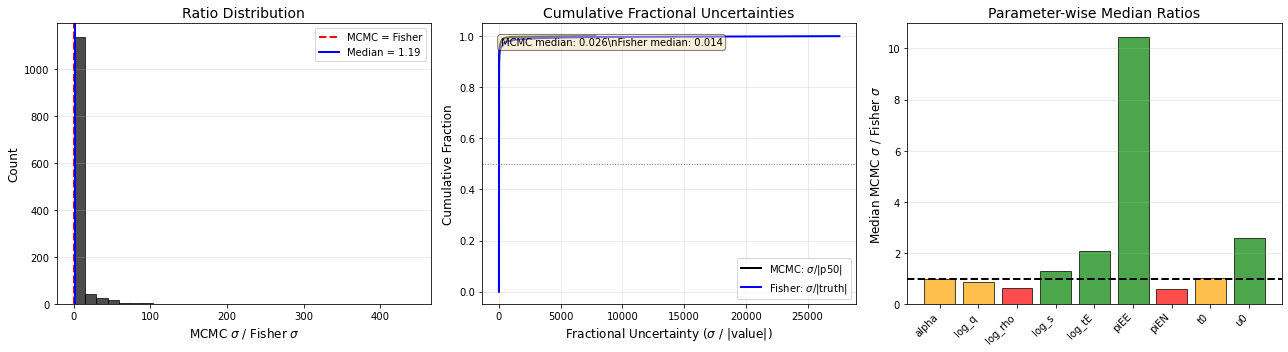

\n=== Global Uncertainty Comparison Summary ===
Number of parameter measurements: 1251
\nMCMC/Fisher Ratio Statistics:
  Mean:   6.869
  Median: 1.189
  Std:    23.170
  Min:    0.003
  Max:    444.267
\n  Q1:     0.529
  Q3:     3.619
\nFraction where MCMC < Fisher: 44.2%
Fraction where MCMC > Fisher: 55.8%
\nParameter-wise median ratios:
  ✓ alpha       : 0.986
  ✓ log_q       : 0.868
  ⚠ log_rho     : 0.640
  ⚠ log_s       : 1.283
  ⚠ log_tE      : 2.061
  ⚠ piEE        : 10.456
  ⚠ piEN        : 0.576
  ✓ t0          : 1.021
  ⚠ u0          : 2.588


In [24]:
# Global comparison of MCMC vs Fisher uncertainties
import matplotlib.pyplot as plt
import numpy as np

# Collect all uncertainty pairs across all events
fisher_sigmas = []
mcmc_sigmas = []
hdf5_sigmas = []
prior_sigmas = []
param_names = []
event_names = []

for mass_bin in completed_bins:
    print(f"Collecting uncertainties from mass bin: {mass_bin}")
    event_list = data[mass_bin]["event_list"]
    
    for prm_file, event_data in event_list.items():
        event_name = f"{event_data['field']}_{event_data['subrun']}_{event_data['event_id']}"
        parameter_labels = event_data['parameter_labels']
        fisher_unc = event_data.get('fisher_uncertainties')
        hdf5_unc = event_data.get('hdf5_uncertainties')
        mcmc_unc = event_data.get('mcmc_uncertainties')
        prior_unc = event_data.get('prior_uncertainties')
        
        for label in parameter_labels:
            label_key = f"log_{label}_err" if label in ["s", "q", "rho", "tE"] else f"{label}_err"
            
            # Get Fisher uncertainty
            if label_key in fisher_unc.index and not np.isnan(fisher_unc[label_key]):
                fisher_sig = fisher_unc[label_key]
                
                # Get MCMC uncertainty (average of + and -)
                if label_key in mcmc_unc:
                    p50, err_minus, err_plus = mcmc_unc[label_key]
                    mcmc_sig = (err_minus + err_plus) / 2.0
                    
                    # Store the pair
                    fisher_sigmas.append(fisher_sig)
                    mcmc_sigmas.append(mcmc_sig)
                    param_names.append(label_key.replace('_err', ''))
                    event_names.append(event_name)
                    
                    # Also get HDF5 and Prior if available
                    if label_key in hdf5_unc.index and not np.isnan(hdf5_unc[label_key]):
                        hdf5_sigmas.append(hdf5_unc[label_key])
                    else:
                        hdf5_sigmas.append(np.nan)
                    
                    if label_key in prior_unc:
                        prior_sigmas.append(prior_unc[label_key])
                    else:
                        prior_sigmas.append(np.nan)

fisher_sigmas = np.array(fisher_sigmas)
mcmc_sigmas = np.array(mcmc_sigmas)
hdf5_sigmas = np.array(hdf5_sigmas)
prior_sigmas = np.array(prior_sigmas)

# Create figure with multiple subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Ratio histogram
ax = axes[0]
ratios = mcmc_sigmas / fisher_sigmas
ax.hist(ratios, bins=30, color='black', alpha=0.7, edgecolor='black')
ax.axvline(1.0, color='r', linestyle='--', linewidth=2, label='MCMC = Fisher')
median_ratio = np.median(ratios)
ax.axvline(median_ratio, color='blue', linestyle='-', linewidth=2, label=f'Median = {median_ratio:.2f}')
ax.set_xlabel('MCMC $\\sigma$ / Fisher $\\sigma$', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Ratio Distribution', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 2. Cumulative fractional uncertainty comparison
ax = axes[1]

# Need to collect fractional errors (need p50 values and truth values)
mcmc_fractional = []
fisher_fractional = []

for mass_bin in completed_bins:
    print(f"Collecting fractional uncertainties from mass bin: {mass_bin}")
    event_list = data[mass_bin]["event_list"]
                                
    for prm_file, event_data in event_list.items():
        parameter_labels = event_data['parameter_labels']
        fisher_unc = event_data.get('fisher_uncertainties', pd.Series())
        mcmc_unc = event_data.get('mcmc_uncertainties', {})
        truths_series = event_data['truths']  # linear space values
        
        for label in parameter_labels:
            label_key = f"log_{label}_err" if label in ["s", "q", "rho", "tE"] else f"{label}_err"
            
            # Get truth value (in correct space)
            if label in ["s", "q", "rho", "tE"]:
                truth_val = np.log10(truths_series[label]) if truths_series[label] > 0 else np.nan
            else:
                truth_val = truths_series[label]
            
            # Get Fisher fractional error: σ_Fisher / |truth|
            if label_key in fisher_unc.index and not np.isnan(fisher_unc[label_key]) and not np.isnan(truth_val) and truth_val != 0:
                fisher_frac = fisher_unc[label_key] / np.abs(truth_val)
                fisher_fractional.append(fisher_frac)
            
            # Get MCMC fractional error: σ_MCMC / |p50| where σ_MCMC = sqrt(err_minus² + err_plus²)
            if label_key in mcmc_unc:
                p50, err_minus, err_plus = mcmc_unc[label_key]
                if p50 != 0 and not np.isnan(p50):
                    sigma_mcmc = np.sqrt(err_minus**2 + err_plus**2)
                    mcmc_frac = sigma_mcmc / np.abs(p50)
                    mcmc_fractional.append(mcmc_frac)

mcmc_fractional = np.array(mcmc_fractional)
fisher_fractional = np.array(fisher_fractional)

# Plot cumulative distributions
sorted_mcmc = np.sort(mcmc_fractional)
cumulative_mcmc = np.arange(1, len(sorted_mcmc) + 1) / len(sorted_mcmc)
ax.plot(sorted_mcmc, cumulative_mcmc, color='black', linewidth=2, label='MCMC: $\\sigma$/|p50|')

sorted_fisher = np.sort(fisher_fractional)
cumulative_fisher = np.arange(1, len(sorted_fisher) + 1) / len(sorted_fisher)
ax.plot(sorted_fisher, cumulative_fisher, color='blue', linewidth=2, label='Fisher: $\\sigma$/|truth|')

ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Fractional Uncertainty ($\\sigma$ / |value|)', fontsize=12)
ax.set_ylabel('Cumulative Fraction', fontsize=12)
ax.set_title('Cumulative Fractional Uncertainties', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Add median annotations
mcmc_median = np.median(mcmc_fractional)
fisher_median = np.median(fisher_fractional)
ax.text(0.05, 0.95, f'MCMC median: {mcmc_median:.3f}\\nFisher median: {fisher_median:.3f}', 
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Parameter-wise comparison (grouped by parameter type)
ax = axes[2]
# Group by parameter name (not by event)
unique_params = sorted(set(param_names))
param_median_ratios = []
for param in unique_params:
    mask = np.array(param_names) == param
    param_ratios = ratios[mask]
    param_median_ratios.append(np.median(param_ratios))

x_pos = np.arange(len(unique_params))
colors = ['red' if r < 0.8 else 'orange' if r < 1.2 else 'green' for r in param_median_ratios]
bars = ax.bar(x_pos, param_median_ratios, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(1.0, color='black', linestyle='--', linewidth=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(unique_params, rotation=45, ha='right')
ax.set_ylabel('Median MCMC $\\sigma$ / Fisher $\\sigma$', fontsize=12)
ax.set_title('Parameter-wise Median Ratios', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(output_dir + 'global_uncertainty_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\\n=== Global Uncertainty Comparison Summary ===")
print(f"Number of parameter measurements: {len(ratios)}")
print(f"\\nMCMC/Fisher Ratio Statistics:")
print(f"  Mean:   {np.mean(ratios):.3f}")
print(f"  Median: {np.median(ratios):.3f}")
print(f"  Std:    {np.std(ratios):.3f}")
print(f"  Min:    {np.min(ratios):.3f}")
print(f"  Max:    {np.max(ratios):.3f}")
print(f"\\n  Q1:     {np.percentile(ratios, 25):.3f}")
print(f"  Q3:     {np.percentile(ratios, 75):.3f}")
print(f"\\nFraction where MCMC < Fisher: {np.sum(ratios < 1.0) / len(ratios):.1%}")
print(f"Fraction where MCMC > Fisher: {np.sum(ratios > 1.0) / len(ratios):.1%}")
print(f"\\nParameter-wise median ratios:")
for param, ratio in zip(unique_params, param_median_ratios):
    status = "✓" if 0.8 < ratio < 1.2 else "⚠"
    print(f"  {status} {param:12s}: {ratio:.3f}")

### Per-Parameter Diagnostics

For each parameter, show:
1. Cumulative fractional uncertainties (MCMC vs Fisher)
2. Uncertainty ratio distribution (MCMC σ / Fisher σ)
3. Posterior bias distribution (p50 - truth)

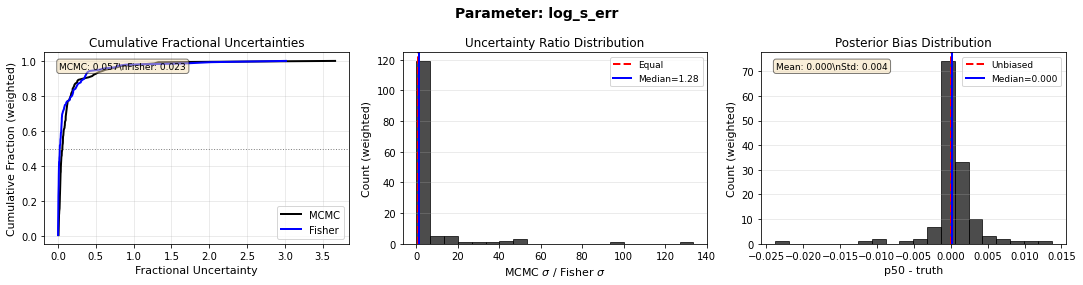

\nlog_s_err Summary (weighted):
  Number of events: 139
  Total weight: 139.00
  MCMC/Fisher ratio: 1.283 (median), 6.379 (mean)
  Posterior bias: 0.000 (median), 0.000 (mean), 0.004 (std)
  Fractional unc: MCMC=0.057, Fisher=0.023


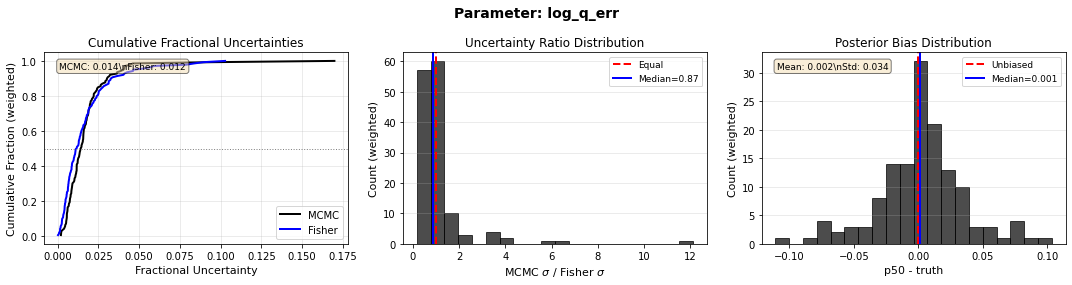

\nlog_q_err Summary (weighted):
  Number of events: 139
  Total weight: 139.00
  MCMC/Fisher ratio: 0.868 (median), 1.154 (mean)
  Posterior bias: 0.001 (median), 0.002 (mean), 0.034 (std)
  Fractional unc: MCMC=0.014, Fisher=0.012


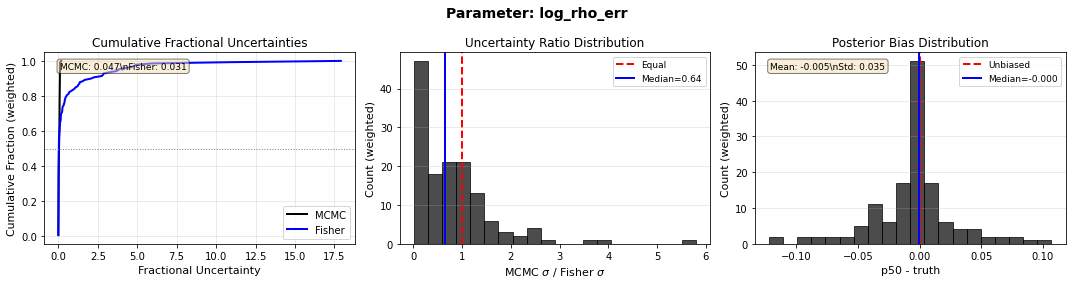

\nlog_rho_err Summary (weighted):
  Number of events: 139
  Total weight: 139.00
  MCMC/Fisher ratio: 0.640 (median), 0.792 (mean)
  Posterior bias: -0.000 (median), -0.005 (mean), 0.035 (std)
  Fractional unc: MCMC=0.047, Fisher=0.031


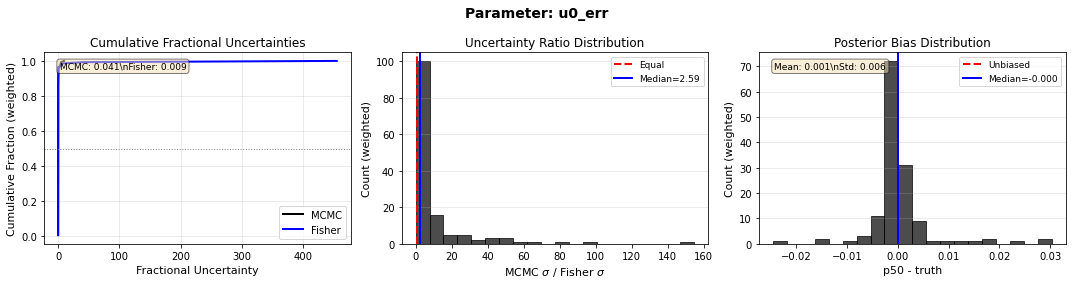

\nu0_err Summary (weighted):
  Number of events: 139
  Total weight: 139.00
  MCMC/Fisher ratio: 2.588 (median), 10.168 (mean)
  Posterior bias: -0.000 (median), 0.001 (mean), 0.006 (std)
  Fractional unc: MCMC=0.041, Fisher=0.009


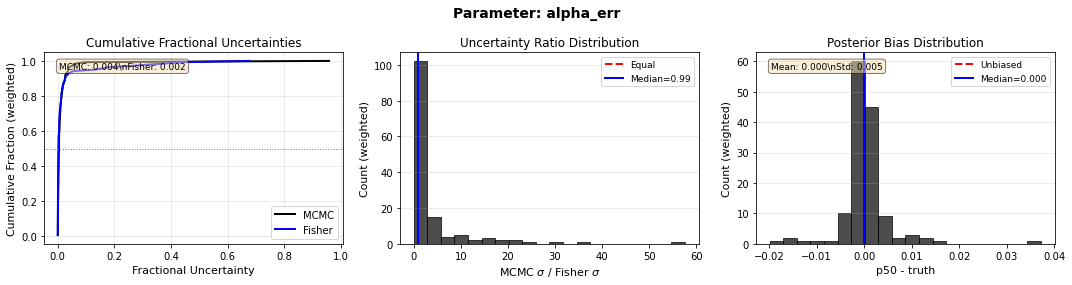

\nalpha_err Summary (weighted):
  Number of events: 139
  Total weight: 139.00
  MCMC/Fisher ratio: 0.986 (median), 3.762 (mean)
  Posterior bias: 0.000 (median), 0.000 (mean), 0.005 (std)
  Fractional unc: MCMC=0.004, Fisher=0.002


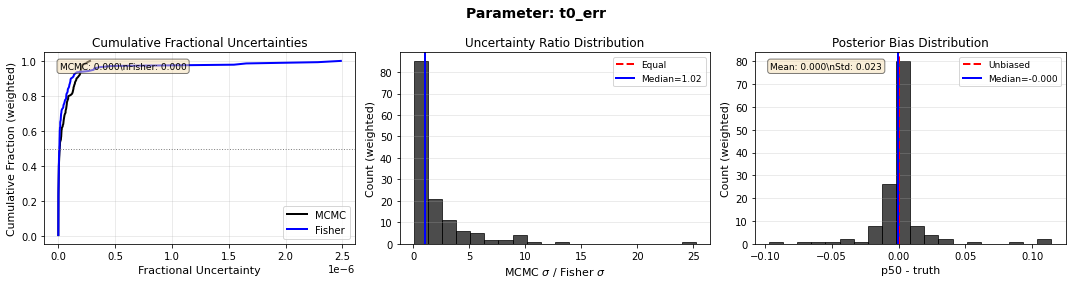

\nt0_err Summary (weighted):
  Number of events: 139
  Total weight: 139.00
  MCMC/Fisher ratio: 1.021 (median), 2.115 (mean)
  Posterior bias: -0.000 (median), 0.000 (mean), 0.023 (std)
  Fractional unc: MCMC=0.000, Fisher=0.000


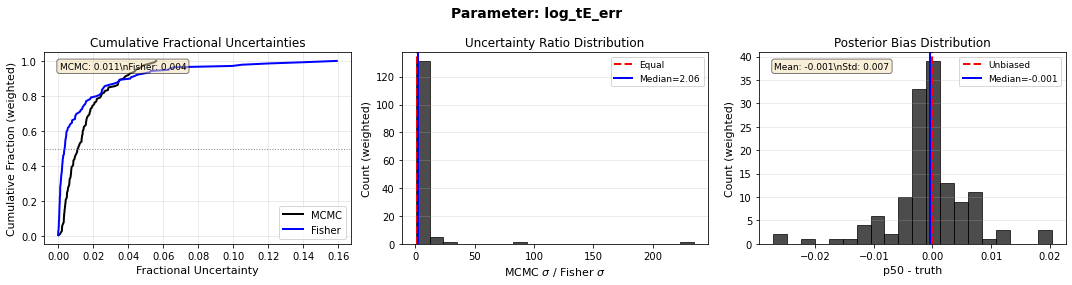

\nlog_tE_err Summary (weighted):
  Number of events: 139
  Total weight: 139.00
  MCMC/Fisher ratio: 2.061 (median), 5.525 (mean)
  Posterior bias: -0.001 (median), -0.001 (mean), 0.007 (std)
  Fractional unc: MCMC=0.011, Fisher=0.004


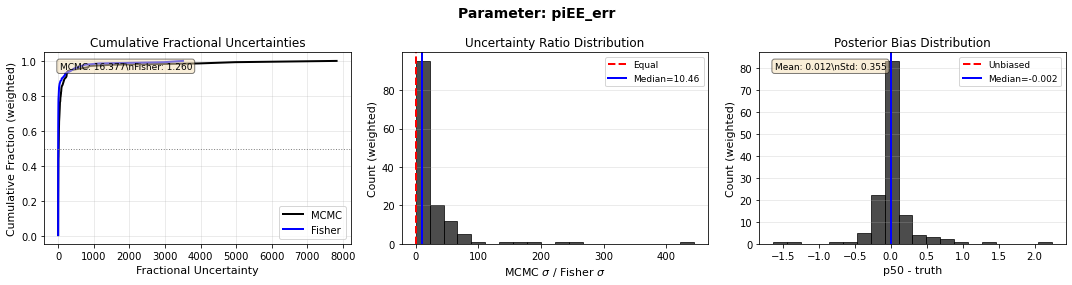

\npiEE_err Summary (weighted):
  Number of events: 139
  Total weight: 139.00
  MCMC/Fisher ratio: 10.456 (median), 28.211 (mean)
  Posterior bias: -0.002 (median), 0.012 (mean), 0.355 (std)
  Fractional unc: MCMC=16.377, Fisher=1.260


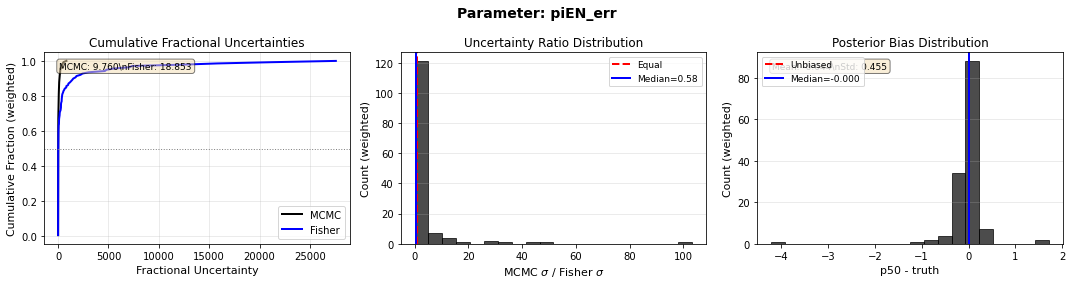

\npiEN_err Summary (weighted):
  Number of events: 139
  Total weight: 139.00
  MCMC/Fisher ratio: 0.576 (median), 3.714 (mean)
  Posterior bias: -0.000 (median), -0.044 (mean), 0.455 (std)
  Fractional unc: MCMC=9.760, Fisher=18.853


In [25]:
# Per-parameter diagnostic plots
import matplotlib.pyplot as plt
import numpy as np

# Organize data by parameter
param_data = {}  # {param_name: {'fisher_frac': [], 'mcmc_frac': [], 'ratios': [], 'bias': [], 'weights': []}}

for mass_bin in completed_bins:
    print(f"Collecting fractional uncertainties from mass bin: {mass_bin}")
    event_list = data[mass_bin]["event_list"]
    
    for prm_file, event_data in event_list.items():
        parameter_labels = event_data['parameter_labels']
        fisher_unc = event_data.get('fisher_uncertainties', pd.Series())
        mcmc_unc = event_data.get('mcmc_uncertainties', {})
        truths_series = event_data['truths']  # linear space values
        simulation_metadata = event_data.get('simulation_metadata', None)
        
        # Get the final weight from HDF5
        event_weight = simulation_metadata['final_weight']
        
        for label in parameter_labels:
            label_key = f"log_{label}_err" if label in ["s", "q", "rho", "tE"] else f"{label}_err"
            
            # Initialize parameter data dict if needed
            if label_key not in param_data:
                param_data[label_key] = {
                    'fisher_frac': [],
                    'mcmc_frac': [],
                    'ratios': [],
                    'bias': [],
                    'weights': []
                }
            
            # Get truth value (in correct space)
            if label in ["s", "q", "rho", "tE"]:
                truth_val = np.log10(truths_series[label]) if truths_series[label] > 0 else np.nan
            else:
                truth_val = truths_series[label]
            
            # Get Fisher fractional error and ratio
            if label_key in fisher_unc.index and not np.isnan(fisher_unc[label_key]):
                fisher_sig = fisher_unc[label_key]
                
                if not np.isnan(truth_val) and truth_val != 0:
                    fisher_frac = fisher_sig / np.abs(truth_val)
                    param_data[label_key]['fisher_frac'].append(fisher_frac)
                    param_data[label_key]['weights'].append(event_weight)
            
            # Get MCMC fractional error, ratio, and bias
            if label_key in mcmc_unc:
                p50, err_minus, err_plus = mcmc_unc[label_key]
                
                if p50 != 0 and not np.isnan(p50):
                    sigma_mcmc = np.sqrt(err_minus**2 + err_plus**2)
                    mcmc_frac = sigma_mcmc / np.abs(p50)
                    param_data[label_key]['mcmc_frac'].append(mcmc_frac)
                
                # Ratio (need both Fisher and MCMC)
                if label_key in fisher_unc.index and not np.isnan(fisher_unc[label_key]):
                    fisher_sig = fisher_unc[label_key]
                    mcmc_sig = (err_minus + err_plus) / 2.0
                    ratio = mcmc_sig / fisher_sig
                    param_data[label_key]['ratios'].append(ratio)
                
                # Bias (p50 - truth)
                if not np.isnan(truth_val):
                    bias = p50 - truth_val
                    param_data[label_key]['bias'].append(bias)


# Create figure for each parameter
for param_name, data in param_data.items():
    if len(data['mcmc_frac']) == 0:
        continue  # Skip if no data
    
    # Convert to arrays
    weights = np.ones_like(np.array(data['mcmc_frac']))  #np.array(data['weights'])
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Parameter: {param_name}", fontsize=14, fontweight='bold')
    
    # 1. Cumulative fractional uncertainties
    ax = axes[0]
    if len(data['mcmc_frac']) > 0:
        mcmc_arr = np.array(data['mcmc_frac'])
        # Sort by values and apply cumulative sum of weights
        sort_idx = np.argsort(mcmc_arr)
        sorted_mcmc = mcmc_arr[sort_idx]
        sorted_weights_mcmc = weights[sort_idx]
        cumulative_mcmc = np.cumsum(sorted_weights_mcmc) / np.sum(sorted_weights_mcmc)
        ax.plot(sorted_mcmc, cumulative_mcmc, color='black', linewidth=2, label='MCMC')
    
    if len(data['fisher_frac']) > 0:
        fisher_arr = np.array(data['fisher_frac'])
        sort_idx = np.argsort(fisher_arr)
        sorted_fisher = fisher_arr[sort_idx]
        sorted_weights_fisher = weights[sort_idx]
        cumulative_fisher = np.cumsum(sorted_weights_fisher) / np.sum(sorted_weights_fisher)
        ax.plot(sorted_fisher, cumulative_fisher, color='blue', linewidth=2, label='Fisher')
    
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Fractional Uncertainty', fontsize=11)
    ax.set_ylabel('Cumulative Fraction (weighted)', fontsize=11)
    ax.set_title('Cumulative Fractional Uncertainties', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add weighted median annotations
    if len(data['mcmc_frac']) > 0 and len(data['fisher_frac']) > 0:
        # Weighted median (approximate as value at 50th percentile)
        mcmc_median_idx = np.searchsorted(cumulative_mcmc, 0.5)
        fisher_median_idx = np.searchsorted(cumulative_fisher, 0.5)
        mcmc_median = sorted_mcmc[min(mcmc_median_idx, len(sorted_mcmc)-1)]
        fisher_median = sorted_fisher[min(fisher_median_idx, len(sorted_fisher)-1)]
        ax.text(0.05, 0.95, f'MCMC: {mcmc_median:.3f}\\nFisher: {fisher_median:.3f}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)
    
    # 2. Uncertainty ratio distribution (weighted histogram)
    ax = axes[1]
    if len(data['ratios']) > 0:
        ratios_arr = np.array(data['ratios'])
        ax.hist(ratios_arr, bins=20, weights=weights, color='black', alpha=0.7, edgecolor='black')
        ax.axvline(1.0, color='r', linestyle='--', linewidth=2, label='Equal')
        # Weighted median
        sort_idx = np.argsort(ratios_arr)
        sorted_ratios = ratios_arr[sort_idx]
        sorted_weights_ratio = weights[sort_idx]
        cumulative_ratios = np.cumsum(sorted_weights_ratio) / np.sum(sorted_weights_ratio)
        median_idx = np.searchsorted(cumulative_ratios, 0.5)
        median_ratio = sorted_ratios[min(median_idx, len(sorted_ratios)-1)]
        ax.axvline(median_ratio, color='blue', linestyle='-', linewidth=2, 
                   label=f'Median={median_ratio:.2f}')
        ax.set_xlabel('MCMC $\\sigma$ / Fisher $\\sigma$', fontsize=11)
        ax.set_ylabel('Count (weighted)', fontsize=11)
        ax.set_title('Uncertainty Ratio Distribution', fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Posterior bias (p50 - truth) (weighted histogram)
    ax = axes[2]
    if len(data['bias']) > 0:
        bias_arr = np.array(data['bias'])
        ax.hist(bias_arr, bins=20, weights=weights, color='black', alpha=0.7, edgecolor='black')
        ax.axvline(0.0, color='r', linestyle='--', linewidth=2, label='Unbiased')
        # Weighted median and mean
        sort_idx = np.argsort(bias_arr)
        sorted_bias = bias_arr[sort_idx]
        sorted_weights_bias = weights[sort_idx]
        cumulative_bias = np.cumsum(sorted_weights_bias) / np.sum(sorted_weights_bias)
        median_idx = np.searchsorted(cumulative_bias, 0.5)
        median_bias = sorted_bias[min(median_idx, len(sorted_bias)-1)]
        mean_bias = np.average(bias_arr, weights=weights)
        ax.axvline(median_bias, color='blue', linestyle='-', linewidth=2, 
                   label=f'Median={median_bias:.3f}')
        ax.set_xlabel('p50 - truth', fontsize=11)
        ax.set_ylabel('Count (weighted)', fontsize=11)
        ax.set_title('Posterior Bias Distribution', fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add weighted statistics text
        # Weighted std: sqrt(sum(w * (x - mean)^2) / sum(w))
        std_bias = np.sqrt(np.average((bias_arr - mean_bias)**2, weights=weights))
        ax.text(0.05, 0.95, f'Mean: {mean_bias:.3f}\\nStd: {std_bias:.3f}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)
    
    plt.tight_layout()
    plt.savefig(output_dir + f'param_diagnostics_{param_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\\n{param_name} Summary (weighted):")
    print(f"  Number of events: {len(data['bias'])}")
    print(f"  Total weight: {np.sum(weights):.2f}")
    if len(data['ratios']) > 0:
        ratios_arr = np.array(data['ratios'])
        sort_idx = np.argsort(ratios_arr)
        sorted_ratios = ratios_arr[sort_idx]
        sorted_weights_ratio = weights[sort_idx]
        cumulative_ratios = np.cumsum(sorted_weights_ratio) / np.sum(sorted_weights_ratio)
        median_idx = np.searchsorted(cumulative_ratios, 0.5)
        median_ratio = sorted_ratios[min(median_idx, len(sorted_ratios)-1)]
        mean_ratio = np.average(ratios_arr, weights=weights)
        print(f"  MCMC/Fisher ratio: {median_ratio:.3f} (median), {mean_ratio:.3f} (mean)")
    if len(data['bias']) > 0:
        bias_arr = np.array(data['bias'])
        sort_idx = np.argsort(bias_arr)
        sorted_bias = bias_arr[sort_idx]
        sorted_weights_bias = weights[sort_idx]
        cumulative_bias = np.cumsum(sorted_weights_bias) / np.sum(sorted_weights_bias)
        median_idx = np.searchsorted(cumulative_bias, 0.5)
        median_bias = sorted_bias[min(median_idx, len(sorted_bias)-1)]
        mean_bias = np.average(bias_arr, weights=weights)
        std_bias = np.sqrt(np.average((bias_arr - mean_bias)**2, weights=weights))
        print(f"  Posterior bias: {median_bias:.3f} (median), {mean_bias:.3f} (mean), {std_bias:.3f} (std)")
    if len(data['mcmc_frac']) > 0 and len(data['fisher_frac']) > 0:
        mcmc_arr = np.array(data['mcmc_frac'])
        fisher_arr = np.array(data['fisher_frac'])
        sort_idx_mcmc = np.argsort(mcmc_arr)
        sort_idx_fisher = np.argsort(fisher_arr)
        sorted_mcmc = mcmc_arr[sort_idx_mcmc]
        sorted_fisher = fisher_arr[sort_idx_fisher]
        sorted_weights_mcmc = weights[sort_idx_mcmc]
        sorted_weights_fisher = weights[sort_idx_fisher]
        cumulative_mcmc = np.cumsum(sorted_weights_mcmc) / np.sum(sorted_weights_mcmc)
        cumulative_fisher = np.cumsum(sorted_weights_fisher) / np.sum(sorted_weights_fisher)
        mcmc_median_idx = np.searchsorted(cumulative_mcmc, 0.5)
        fisher_median_idx = np.searchsorted(cumulative_fisher, 0.5)
        mcmc_median = sorted_mcmc[min(mcmc_median_idx, len(sorted_mcmc)-1)]
        fisher_median = sorted_fisher[min(fisher_median_idx, len(sorted_fisher)-1)]
        print(f"  Fractional unc: MCMC={mcmc_median:.3f}, Fisher={fisher_median:.3f}")

## Filter by 

## TODO

### Urgent:
[x] fix the bug that is killing the runs  
[x] ensure final plots are being made and VBM params are being saved  
    [ ] fix VBM save bug
[x] add Fs and FB to the samples (now saved per-observatory via blobs)
[x] fix FB prior (changed sigma_fb from 50 to 0.2)
[ ] Smoosh flux plots together (overlay different filters in different colours)

### Not Urgent:
[ ] exclude the ones that hit a prior bound  
[ ] talk to Matt and Farz about how they approached this
[ ] add Fs and FB to the corner plots
